# Relatório de Performance

**Repositório:** https://github.com/FigLucas/Simulador-de-e-Livro-de-Ofertas-e-Performance-de-Estruturas

## Objetivo

Este notebook analisa o desempenho do código feito no projeto. A análise se dá por meio das:

- **Análise teórica**: olhando o custo das operações
- **Análise empírica**: medindo tempos para volumes diferentes de ordens

# 1. Importação das classes do projeto

In [32]:
from pathlib import Path
import sys
import time
import random
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "figure.figsize": (10, 6),
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "grid.alpha": 0.7
})

if Path.cwd().name == "notebook":
    path_p = Path.cwd().parent
else:
    path_p = Path.cwd()

if str(path_p) not in sys.path:
    sys.path.append(str(path_p))

from src.order import Ordem
from src.queue import Fila
from src.stack import Pilha
from src.order_book import LivroOfertas, MotorNegociacao
from src.simulator import Simulador

print("Importações realizadas!")

Importações realizadas!


# 2. Estruturas usadas

O código usa as seguintes estruturas:

## Fila

A classe `Fila` guarda as ordens antes de elas entrarem no livro. Ela segue a regra FIFO, onde a primeira ordem inserida é a primeira removida. Como a fila guarda referência para o início e para o fim, inserir no fim e remover do início custam $O(1)$.

## Pilha

A classe `Pilha` é usada para o undo. Ela segue a regra LIFO, então o último ID inserido é o primeiro removido. Como tudo acontece no topo, as operações principais custam $O(1)$.

## Livro de Ofertas

A classe `LivroOfertas` possui duas listas duplamente encadeadas:

- `compras`: ordenada por maior preço primeiro;
- `vendas`: ordenada por menor preço primeiro.

A inserção no livro chama `inserir_ordem`. Esse método verifica se a ordem já existe e depois coloca a ordem na lista correta. Como a lista encadeada precisa ser percorrida nó por nó, a busca e a inserção ordenada podem custar $O(n)$.

Além disso, o motor usa `RegistroIds` para guardar os IDs já recebidos. Como esse registro também é uma lista encadeada simples, o método `RegistroIds.contem` faz uma busca sequencial antes de colocar uma nova ordem na fila. Portanto, a validação de duplicidade aparece em dois momentos do fluxo completo: primeiro no motor, por `RegistroIds.contem`, e depois no livro, por `LivroOfertas.ordem_existe`.

# 3. Complexidade teórica

| Parte do código | Operação | Complexidade |
|---|---|---:|
| `Fila.insere` | inserir no fim da fila | $O(1)$ |
| `Fila.remove` | remover do início da fila | $O(1)$ |
| `Pilha.empilha` | inserir no topo | $O(1)$ |
| `Pilha.desempilha` | remover do topo | $O(1)$ |
| `RegistroIds.contem` | verificar se um ID já foi recebido | $O(n)$ |
| `RegistroIds.adicionar` | registrar um novo ID no fim da lista | $O(1)$ |
| `LivroOfertas.ordem_existe` | procurar uma ordem pelo ID | $O(n)$ |
| `LivroOfertas.inserir_ordem` | inserir na lista de compras ou vendas | $O(n)$ |
| `LivroOfertas.remover_ordem_por_id` | procurar e remover pelo ID | $O(n)$ |
| `LivroOfertas.obter_melhor_compra` | acessar o primeiro nó de compras | $O(1)$ |
| `LivroOfertas.obter_melhor_venda` | acessar o primeiro nó de vendas | $O(1)$ |

Se há n ordens no livro, uma busca em lista encadeada pode precisar olhar até n nós. Quando processamos muitas ordens, esse custo vai se repetindo. No pior caso, a soma dos percursos fica parecida com:

$$1 + 2 + 3 + \cdots + (n-1) = \frac{n(n-1)}{2}$$

Assim, o custo esperado para o fluxo completo fica próximo de $O(n^2)$. Esse crescimento não vem de uma única operação isolada, mas da repetição de várias buscas lineares: a verificação de ID em `RegistroIds`, a verificação de existência no `LivroOfertas` e a própria inserção ordenada nas listas de compra e venda.

# 4. Teste do Simulador

A classe `Simulador`, cria ordens aleatórias para testar o sistema. Primeiro vamos medir apenas o tempo para gerar ordens.

In [33]:
simulador = Simulador()

quantidades = [1000, 2000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
resultados_geracao = []

for quantidade in quantidades:
    random.seed(42)
    tempo = simulador.medir_tempo_execucao(lambda quantidade=quantidade: simulador.gerar_ordens(quantidade))

    resultados_geracao.append({
        "quantidade": quantidade,
        "tempo": tempo
    })

try:
    import pandas as pd
    display(pd.DataFrame(resultados_geracao))
except ImportError:
    for resultado in resultados_geracao:
        print(resultado)

,quantidade,tempo
0,1000,0.002950
1,2000,0.004750
2,4000,0.013947
3,5000,0.008740
4,6000,0.010496
5,7000,0.009307
6,8000,0.011254
7,9000,0.011636
8,10000,0.013855


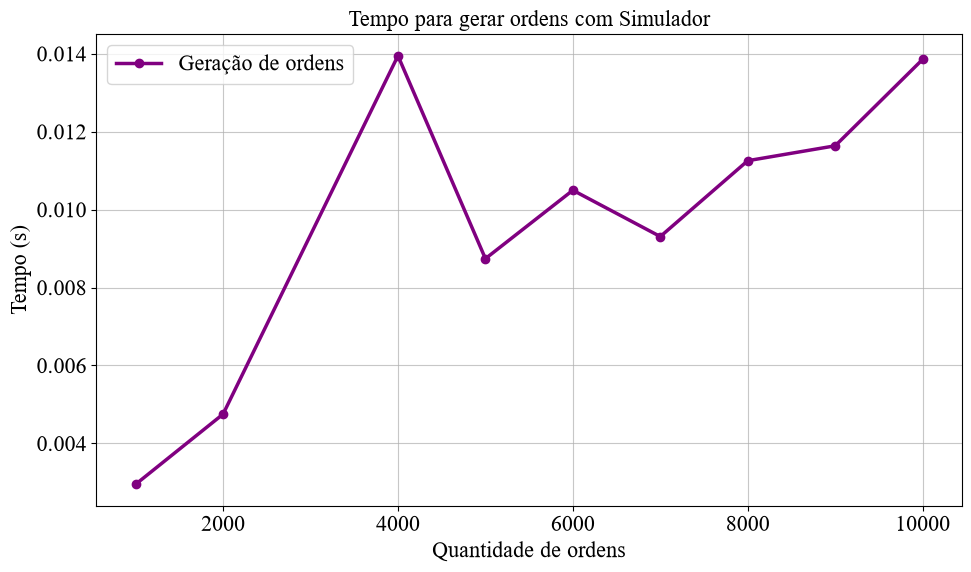

In [34]:
x = []
y = []

for resultado in resultados_geracao:
    x.append(resultado["quantidade"])
    y.append(resultado["tempo"])

plt.figure()
plt.plot(x, y, marker="o", linewidth=2.5, color="purple", label="Geração de ordens")
plt.title("Tempo para gerar ordens com Simulador")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Análise empírica do fluxo completo

Agora o teste mede o fluxo completo:

1. gerar ordens com `Simulador.gerar_ordens`;
2. criar uma `Fila`;
3. criar um `LivroOfertas`;
4. criar uma `Pilha`;
5. criar o `MotorNegociacao`;
6. receber as ordens com `receber_nova_ordem`;
7. processar tudo com `processar_fila_para_o_livro`.

Este é o teste principal, pois usa o código do projeto como ele foi feito.

In [35]:
quantidades = [1000, 2000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
resultados_fluxo = []

for quantidade in quantidades:
    random.seed(42)
    ordens = simulador.gerar_ordens(quantidade)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()

    for ordem in ordens:
        motor.receber_nova_ordem(ordem)

    motor.processar_fila_para_o_livro()

    fim = time.time()

    resultados_fluxo.append({
        "quantidade": quantidade,
        "tempo": fim - inicio,
        "compras_restantes": livro_ofertas.compras.size,
        "vendas_restantes": livro_ofertas.vendas.size,
        "total_restante": livro_ofertas.total_ordens()
    })

try:
    display(pd.DataFrame(resultados_fluxo))
except NameError:
    for resultado in resultados_fluxo:
        print(resultado)

,quantidade,tempo,compras_restantes,vendas_restantes,total_restante
0,1000,0.018143,104,139,243
1,2000,0.063723,235,256,491
2,4000,0.241697,488,479,967
3,5000,0.369078,570,610,1180
4,6000,0.637419,691,700,1391
5,7000,0.745366,842,795,1637
6,8000,0.978392,923,911,1834
7,9000,1.292178,1037,1038,2075
8,10000,1.461348,1130,1149,2279


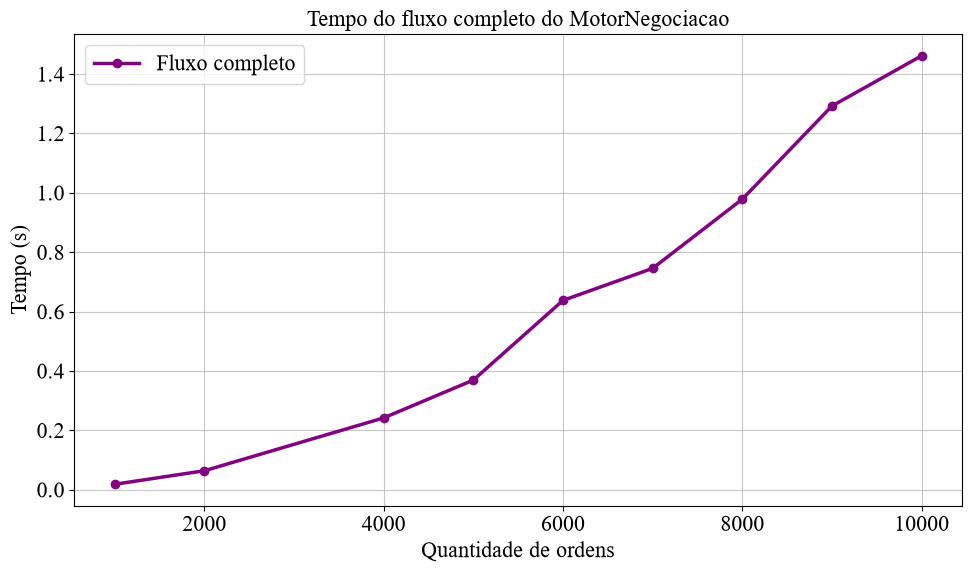

In [36]:
x = []
y = []

for resultado in resultados_fluxo:
    x.append(resultado["quantidade"])
    y.append(resultado["tempo"])

plt.figure()
plt.plot(x, y, marker="o", linewidth=2.5, color="purple", label="Fluxo completo")
plt.title("Tempo do fluxo completo do MotorNegociacao")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Comparação entre melhor caso e pior caso de inserção

## Melhor caso

Foram criadas ordens de compra com preço crescente. Como a lista de compras coloca o maior preço no início, cada nova ordem tende a entrar no começo.

## Pior caso

Foram criadas ordens de compra com preço decrescente. Nesse caso, cada nova ordem tende a entrar no final da lista, então a lista precisa ser percorrida por mais tempo.

Mesmo no melhor caso de posição, o fluxo completo ainda possui buscas lineares auxiliares. O método `MotorNegociacao.receber_nova_ordem` chama `RegistroIds.contem` para evitar IDs repetidos, e o método `LivroOfertas.inserir_ordem` chama `ordem_existe`, que também faz busca pelo ID. Por isso, mesmo quando a posição de inserção é encontrada rapidamente, o custo total continua mais alto do que apenas inserir no início da lista.

In [37]:
quantidades = [1000, 2000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
resultados_casos = []

for quantidade in quantidades:
    ordens = Fila()
    for i in range(quantidade):
        ordem = Ordem(i, "C", i + 1, 1, i)
        ordens.insere(ordem)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()
    for ordem in ordens:
        motor.receber_nova_ordem(ordem)
    motor.processar_fila_para_o_livro()
    fim = time.time()

    resultados_casos.append({
        "quantidade": quantidade,
        "caso": "melhor_posicao",
        "tempo": fim - inicio
    })

    ordens = Fila()
    for i in range(quantidade):
        ordem = Ordem(i, "C", quantidade - i, 1, i)
        ordens.insere(ordem)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()
    for ordem in ordens:
        motor.receber_nova_ordem(ordem)
    motor.processar_fila_para_o_livro()
    fim = time.time()

    resultados_casos.append({
        "quantidade": quantidade,
        "caso": "pior_posicao",
        "tempo": fim - inicio
    })

try:
    display(pd.DataFrame(resultados_casos))
except NameError:
    for resultado in resultados_casos:
        print(resultado)

,quantidade,caso,tempo
0,1000,melhor_posicao,0.022958
1,1000,pior_posicao,0.053323
2,2000,melhor_posicao,0.083584
3,2000,pior_posicao,0.200787
4,4000,melhor_posicao,0.358275
5,4000,pior_posicao,0.817959
6,5000,melhor_posicao,0.567415
7,5000,pior_posicao,1.345176
8,6000,melhor_posicao,0.867529
9,6000,pior_posicao,1.901014


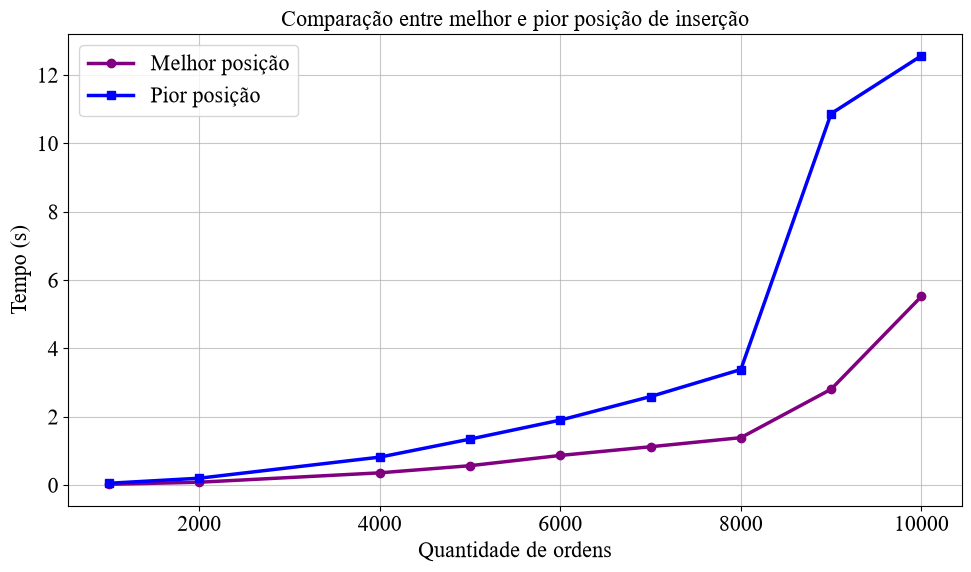

In [38]:
x_melhor = []
y_melhor = []
x_pior = []
y_pior = []

for resultado in resultados_casos:
    if resultado["caso"] == "melhor_posicao":
        x_melhor.append(resultado["quantidade"])
        y_melhor.append(resultado["tempo"])
    else:
        x_pior.append(resultado["quantidade"])
        y_pior.append(resultado["tempo"])

plt.figure()
plt.plot(x_melhor, y_melhor, marker="o", linewidth=2.5, color="purple", label="Melhor posição")
plt.plot(x_pior, y_pior, marker="s", linewidth=2.5, color="blue", label="Pior posição")
plt.title("Comparação entre melhor e pior posição de inserção")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 7. Teste com os matchs

Neste teste, metade das ordens é de compra e metade é de venda. Os preços são escolhidos para permitir o match de ordens.

Assim, além da inserção no livro, o método `processar_match` também trabalha removendo ordens executadas.

In [39]:
quantidades = [100, 500, 1000, 2000, 4000, 8000, 16000]
resultados_match = []

for quantidade in quantidades:
    ordens = Fila()
    metade = quantidade // 2

    for i in range(metade):
        ordem = Ordem(i, "C", 200.0, 1, i)
        ordens.insere(ordem)

    for i in range(metade, quantidade):
        ordem = Ordem(i, "V", 100.0, 1, i)
        ordens.insere(ordem)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()
    for ordem in ordens:
        motor.receber_nova_ordem(ordem)
    motor.processar_fila_para_o_livro()
    fim = time.time()

    resultados_match.append({
        "quantidade": quantidade,
        "tempo": fim - inicio,
        "compras_restantes": livro_ofertas.compras.size,
        "vendas_restantes": livro_ofertas.vendas.size,
        "total_restante": livro_ofertas.total_ordens()
    })

try:
    display(pd.DataFrame(resultados_match))
except NameError:
    for resultado in resultados_match:
        print(resultado)

,quantidade,tempo,compras_restantes,vendas_restantes,total_restante
0,100,0.001251,0,0,0
1,500,0.017401,0,0,0
2,1000,0.068341,0,0,0
3,2000,0.228833,0,0,0
4,4000,0.933962,0,0,0
5,8000,3.736357,0,0,0
6,16000,15.846235,0,0,0


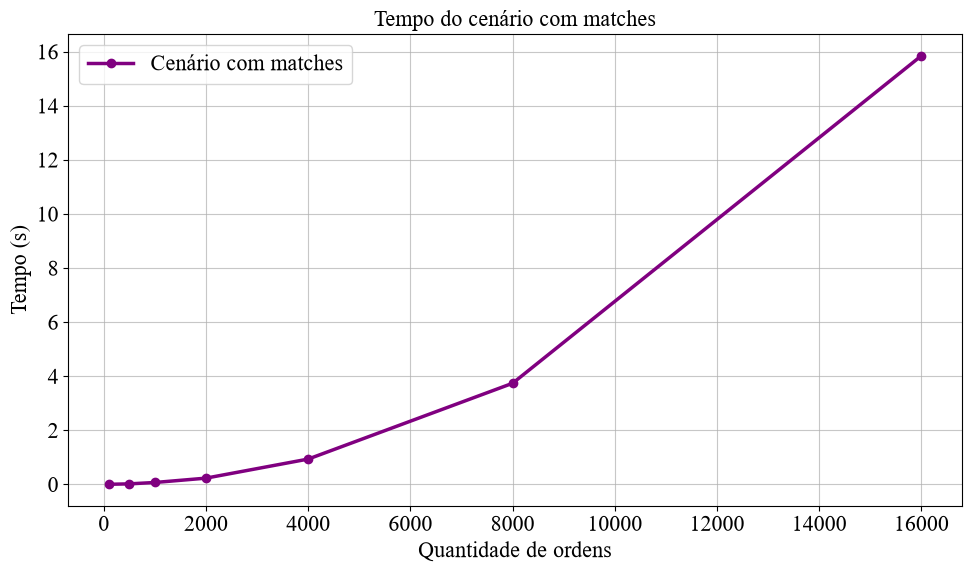

In [40]:
x = []
y = []

for resultado in resultados_match:
    if resultado["tempo"] > 0:
        x.append(resultado["quantidade"])
        y.append(resultado["tempo"])

plt.figure()
plt.plot(x, y, marker="o", linewidth=2.5, color="purple", label="Cenário com matches")

plt.title("Tempo do cenário com matches")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 8. Ajuste de uma curva quadrática O(n²)

In [41]:
x = []
y = []

for resultado in resultados_fluxo:
    x.append(resultado["quantidade"])
    y.append(resultado["tempo"])
x = np.array(x, dtype=float)
y = np.array(y, dtype=float)

# Ajuste polinomial de grau 2 por mínimos quadrados
coeficientes = np.polyfit(x, y, deg=2)
a = coeficientes[0]
b = coeficientes[1]
c = coeficientes[2]
modelo_quadratico = np.poly1d(coeficientes)
y_ajustado = modelo_quadratico(x)

#Cálculo do R quadrado
r2 = 1 - (np.sum((y - y_ajustado) ** 2) / np.sum((y - np.mean(y)) ** 2))

print(f"Modelo ajustado:")
print(f"T(n) = {a:.12e} * n² + {b:.12e} * n + {c:.12e}")
print(f"R² = {r2:.4f}")

Modelo ajustado:
T(n) = 1.314386481304e-08 * n² + 2.204370562729e-05 * n + -3.122462934377e-02
R² = 0.9943


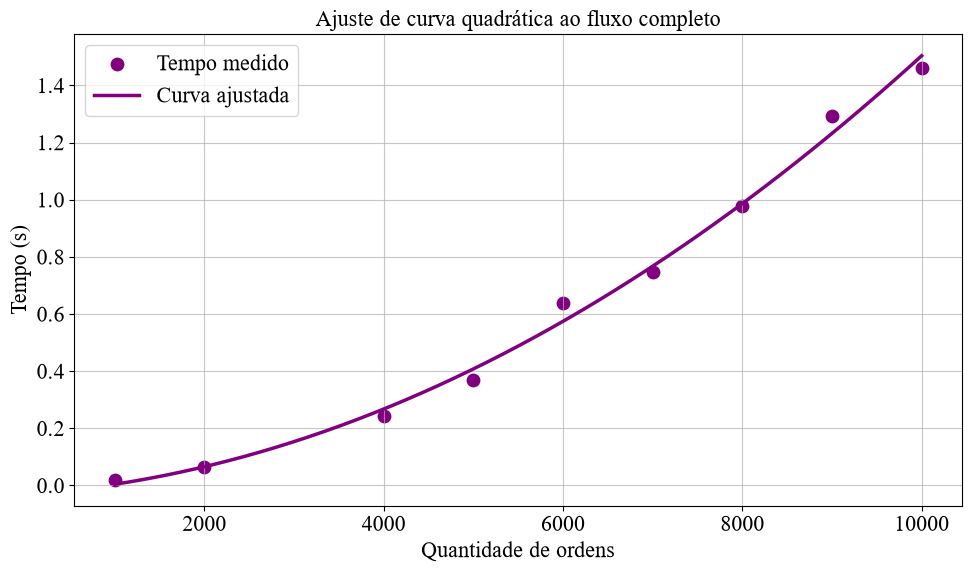

In [42]:
x_suave = np.linspace(x.min(), x.max(), 200)
y_suave = modelo_quadratico(x_suave)

plt.figure()
plt.scatter(x, y, color="purple", s=80, label="Tempo medido")
plt.plot(x_suave, y_suave, color="purple", linewidth=2.5, label="Curva ajustada")
plt.title(r"Ajuste de curva quadrática ao fluxo completo")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 9. Interpretação dos resultados

A partir dos testes realizados, é possível observar que as diferentes partes do sistema possuem custos bem diferentes.

O primeiro teste mediu apenas a geração de ordens pelo `Simulador.gerar_ordens`. Nesse caso, o crescimento do tempo é relativamente baixo e próximo de linear, pois o simulador apenas cria uma ordem por repetição, atribuindo ID, tipo, preço, quantidade e timestamp. Como não há inserção no livro de ofertas nem busca em estruturas encadeadas, essa etapa não representa o principal custo do projeto.

O teste do fluxo completo apresentou crescimento mais acentuado. Esse resultado é esperado, pois o fluxo completo inclui a entrada das ordens na fila, o processamento pelo `MotorNegociacao`, a inserção no `LivroOfertas`, o empilhamento do ID na pilha de undo e a verificação de possíveis matchs. Embora a fila e a pilha tenham operações principais de custo constante, o livro de ofertas usa listas duplamente encadeadas ordenadas. Dessa forma, cada nova ordem pode exigir um percurso sequencial pelos nós até encontrar a posição correta de inserção.

Além disso, a validação de ID repetido ocorre em dois pontos do fluxo. Primeiro, `MotorNegociacao.receber_nova_ordem` chama `RegistroIds.contem`, que percorre a lista de IDs já recebidos. Depois, antes de inserir uma ordem no livro, o método `LivroOfertas.inserir_ordem` chama `ordem_existe`, que também percorre as listas para verificar se já existe uma ordem com o mesmo ID. Portanto, mesmo em situações em que a ordem é inserida rapidamente no início da lista, ainda existe um custo de busca associado à validação da ordem.

A comparação entre melhor e pior posição de inserção deixou esse comportamento mais claro. No melhor caso, as ordens de compra foram criadas com preços crescentes. Como a lista de compras é mantida em ordem decrescente de preço, cada nova ordem tende a ser inserida no início da lista. Isso reduz o percurso necessário para encontrar a posição de inserção. Já no pior caso, as ordens foram criadas com preços decrescentes. Nesse cenário, cada nova ordem tende a ser colocada no final da lista, obrigando o algoritmo a percorrer uma quantidade maior de nós. Por isso, o tempo do pior caso cresce de forma muito mais intensa.

Mesmo assim, o melhor caso também apresenta crescimento relevante, pois as verificações de ID continuam sendo feitas de forma sequencial. Isso mostra que o custo do sistema não depende apenas da posição de inserção, mas também das buscas auxiliares realizadas pelo motor e pelo livro.

No cenário com matchs, o tempo também cresce de forma significativa. Nesse teste, foram criadas ordens de compra e venda compatíveis, de modo que o motor de negociação precisasse executar transações. A comparação entre a melhor compra e a melhor venda é rápida, pois ambas estão no início das listas. Porém, quando uma ordem é totalmente executada, o sistema precisa removê-la do livro. Como a remoção é feita por ID, ela depende novamente de uma busca sequencial. Assim, o cenário com matchs adiciona operações de atualização e remoção ao custo de inserção, tornando o processamento mais pesado.

O ajuste de curva quadrática por mínimos quadrados confirmou a análise teórica. A curva ajustada ficou próxima dos pontos medidos no fluxo completo, indicando que o crescimento observado é compatível com uma tendência quadrática. Além disso, a comparação com outros modelos mostrou que o comportamento do fluxo completo é melhor explicado por uma curva de crescimento acelerado do que por uma curva linear simples.

Esse resultado está de acordo com a análise assintótica feita anteriormente. Como operações de busca, inserção ordenada, validação de IDs e remoção por ID podem custar O(n), e essas operações são repetidas para muitas ordens, o custo acumulado tende a se aproximar de O(n²). Portanto, os gráficos confirmam empiricamente que o principal custo do sistema está nas operações sequenciais realizadas no motor de negociação e no `LivroOfertas`.


# 10. Conclusão

O projeto implementa um simulador de livro de ofertas utilizando estruturas lineares construídas manualmente com nós e referências. Foram usadas uma fila para armazenar ordens antes do processamento, uma pilha para o sistema de undo e listas duplamente encadeadas ordenadas para representar o livro de compras e vendas.

A análise teórica mostrou que as operações principais da fila e da pilha possuem custo O(1), pois trabalham diretamente nas extremidades das estruturas. A fila insere no fim e remove do início, seguindo a política FIFO. A pilha insere e remove pelo topo, seguindo a política LIFO. Por isso, essas estruturas não representam o maior custo do sistema.

O maior impacto no desempenho está nas operações sequenciais do fluxo completo, principalmente no `LivroOfertas` e nas validações de ID feitas pelo motor. Como as listas de compra e venda precisam permanecer ordenadas por preço e timestamp, a inserção de uma nova ordem pode exigir o percurso sequencial da lista até encontrar a posição correta. Além disso, operações como verificar se uma ordem já existe, consultar se um ID já foi recebido em `RegistroIds` e remover uma ordem por ID também dependem de busca sequencial. Portanto, essas operações possuem custo O(n) no pior caso.

Os testes empíricos confirmaram essa análise. A geração simples de ordens apresentou crescimento baixo, pois apenas cria objetos. Já o fluxo completo apresentou crescimento mais acelerado, pois envolve a inserção e a busca em listas encadeadas ordenadas. A comparação entre melhor e pior posição de inserção mostrou que o tempo aumenta bastante quando as ordens precisam ser inseridas no final da lista. O cenário com matches também apresentou crescimento significativo, pois envolve atualização de quantidades e remoção de ordens executadas.

O ajuste quadrático por mínimos quadrados mostrou que os tempos medidos no fluxo completo se aproximam de uma curva de crescimento quadrático. Isso indica que, na prática, o comportamento do sistema está alinhado com a análise teórica. Como várias operações de custo O(n) são repetidas durante o processamento de muitas ordens, incluindo buscas no livro e no registro de IDs, o custo total tende a se aproximar de O(n²).